In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
%matplotlib inline

In [2]:
file_path = "star_classification.csv"
df = pd.read_csv(file_path)
df.head()

,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
0,1.237661e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,2,79,6.543777e+18,GALAXY,0.634794,5812,56354,171
1,1.237665e+18,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,5,119,1.176014e+19,GALAXY,0.779136,10445,58158,427
2,1.237661e+18,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,2,120,5.152200e+18,GALAXY,0.644195,4576,55592,299
3,1.237663e+18,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,3,214,1.030107e+19,GALAXY,0.932346,9149,58039,775
4,1.237680e+18,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,301,3,137,6.891865e+18,GALAXY,0.116123,6121,56187,842


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   obj_ID       100000 non-null  float64
 1   alpha        100000 non-null  float64
 2   delta        100000 non-null  float64
 3   u            100000 non-null  float64
 4   g            100000 non-null  float64
 5   r            100000 non-null  float64
 6   i            100000 non-null  float64
 7   z            100000 non-null  float64
 8   run_ID       100000 non-null  int64  
 9   rerun_ID     100000 non-null  int64  
 10  cam_col      100000 non-null  int64  
 11  field_ID     100000 non-null  int64  
 12  spec_obj_ID  100000 non-null  float64
 13  class        100000 non-null  object 
 14  redshift     100000 non-null  float64
 15  plate        100000 non-null  int64  
 16  MJD          100000 non-null  int64  
 17  fiber_ID     100000 non-null  int64  
dtypes: float64(10), int64(7),

In [4]:
df.shape

(100000, 18)

In [5]:
enc = LabelEncoder()
df['class'] = enc.fit_transform(df['class'])
df.head()

,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
0,1.237661e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,2,79,6.543777e+18,0,0.634794,5812,56354,171
1,1.237665e+18,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,5,119,1.176014e+19,0,0.779136,10445,58158,427
2,1.237661e+18,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,2,120,5.152200e+18,0,0.644195,4576,55592,299
3,1.237663e+18,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,3,214,1.030107e+19,0,0.932346,9149,58039,775
4,1.237680e+18,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,301,3,137,6.891865e+18,0,0.116123,6121,56187,842


In [6]:
X = df.drop(['class'], axis=1)
y = df['class']
X = StandardScaler().fit_transform(X)

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X,y,random_state=42)

In [8]:
X_train = torch.tensor(X_train, dtype = torch.float32)
y_train = torch.tensor(y_train.values, dtype = torch.long)

X_test = torch.tensor(X_test, dtype = torch.float32)
y_test = torch.tensor(y_test.values, dtype = torch.long)

In [9]:
train_ds = TensorDataset(X_train, y_train)
test_ds = TensorDataset(X_test, y_test)

batch_size=64
train_l = DataLoader(train_ds, batch_size=64, shuffle=True)
test_l = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

In [10]:
class StellarClassificationMLP(nn.Module):
    def __init__(self):
        super().__init__()

        self.ll1 = nn.Linear(17,128)
        self.ll2 = nn.Linear(128,64)
        self.ll3 = nn.Linear(64,32)

        self.bn1 = nn.BatchNorm1d(128)
        self.bn2 = nn.BatchNorm1d(64)
        self.bn3 = nn.BatchNorm1d(32)

        self.op = nn.Linear(32,3)
    
    def forward(self, x):
        x = self.ll1(x)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.ll2(x)
        x = self.bn2(x)
        x = F.relu(x)
        x = self.ll3(x)
        x = self.bn3(x)
        x = F.relu(x)
        x = self.op(x)
        return x
    
model = StellarClassificationMLP()
print(model)


StellarClassificationMLP(
  (ll1): Linear(in_features=17, out_features=128, bias=True)
  (ll2): Linear(in_features=128, out_features=64, bias=True)
  (ll3): Linear(in_features=64, out_features=32, bias=True)
  (bn1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn3): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (op): Linear(in_features=32, out_features=3, bias=True)
)


In [11]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr = 0.0001)

In [12]:
epochs = 10

tr_losses = []
te_losses = []

for epoch in range(epochs):
    
    #training
    model.train()
    tr_b_loss = []
    for X_batch, y_batch in train_l:
        pred = model(X_batch)
        loss = criterion(pred, y_batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        tr_b_loss.append(loss.item())
    tr_losses.append(np.mean(tr_b_loss))

    #testing
    model.eval()
    te_b_loss = []
    with torch.no_grad():
        for X_batch, y_batch in test_l:
            pred = model(X_batch)
            loss = criterion(pred, y_batch)
            te_b_loss.append(loss.item())
    te_losses.append(np.mean(te_b_loss))

    if(epoch+1)%2==0:
        print(f" Epoch: {epoch+1:2d}/{epochs} | Train loss: {tr_losses[-1]:.4f} | Test loss: {te_losses[-1]:.4f}")
    

 Epoch:  2/10 | Train loss: 0.2475 | Test loss: 0.2316
 Epoch:  4/10 | Train loss: 0.1804 | Test loss: 0.1532
 Epoch:  6/10 | Train loss: 0.1606 | Test loss: 0.1365
 Epoch:  8/10 | Train loss: 0.1499 | Test loss: 0.1299
 Epoch: 10/10 | Train loss: 0.1424 | Test loss: 0.1216


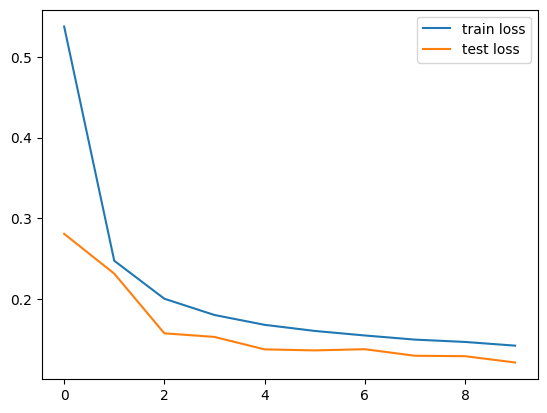

In [13]:
plt.plot(tr_losses, label = "train loss")
plt.plot(te_losses, label = "test loss")
plt.legend()

In [14]:
model.eval()
with torch.no_grad():
    pred = model(X_test)
    classes = torch.argmax(pred, dim=1)

print(confusion_matrix(y_test, classes))
print(classification_report(y_test, classes, target_names = enc.classes_))

[[14492   165   238]
 [  400  4361     8]
 [   89     0  5247]]
              precision    recall  f1-score   support

      GALAXY       0.97      0.97      0.97     14895
         QSO       0.96      0.91      0.94      4769
        STAR       0.96      0.98      0.97      5336

    accuracy                           0.96     25000
   macro avg       0.96      0.96      0.96     25000
weighted avg       0.96      0.96      0.96     25000

